# Setup
If you have not run the below code in a separate Julia session, this notebook will not work.
```
using Pkg
Pkg.add("DrWatson")          
Pkg.activate("path/to/temp-tune")
Pkg.instantiate()

cd("path/to/temp-tune")
include(scriptsdir("setup_python.jl"))
```

## activate project

In [1]:
using Pkg
using DrWatson
@quickactivate "temp-tune"
println("current active project = ",Base.active_project())

current active project = /Users/pfields/Git/temp-tune/Project.toml


## setup plotting

In [2]:
include(srcdir("matplotlib_helpers.jl"))
setup_notebook_for_paper()
using_Py(true)

setup_rc_reset()
set_plot_style_for_paper(; venue="revtex")

Plot style set → venue=revtex, font='Arial'
Sizes (pt): label=10.0  tick=8.0  legend=8.0  mathtext.fontset=cm
Python     : /Users/pfields/Git/temp-tune/.conda/bin/python
Matplotlib : 3.10.8 | backend=Agg
 set plot style finished. exiting...



## other packages

In [18]:
using StatsBase, Statistics, LinearAlgebra, Printf, Random
using SpecialFunctions
using Parameters, Flux
using Optim, BenchmarkTools, JLD2, DataFrames, Graphs
using OptimizationOptimJL, Optimization
using Roots, Expectations
using Distributions
using Conda
using SpinModels

# illustrative toy model

In [4]:
include(srcdir("two_level_toy_model.jl"))

get_dkl (generic function with 1 method)

### generate training data

In [11]:
Δtrue   =5
nlevels = 2 # always only two levels (ground and excited levels)
nexcited=20
nground=10
nsampss = 30
N_states=nground+nexcited

ees, lbls = etrues(Δtrue,nlevels,nexcited,nground)
true_probs=get_probs_2( ees )

sampless=get_samples(true_probs, nsampss, N_states );
freqs = get_freqs(sampless, lbls); # empirical distribution

### fit model

In [12]:
minlosses, Δ̂, L̂i, pfit, Δs, Lp, minl_m_to_l =fit_n_ground_and_Δ_hard_constraint( freqs, 
                                                        nsampss; make_pfit=true, λ=0);
m_to_l=reverse(sortperm(freqs));

### plot results

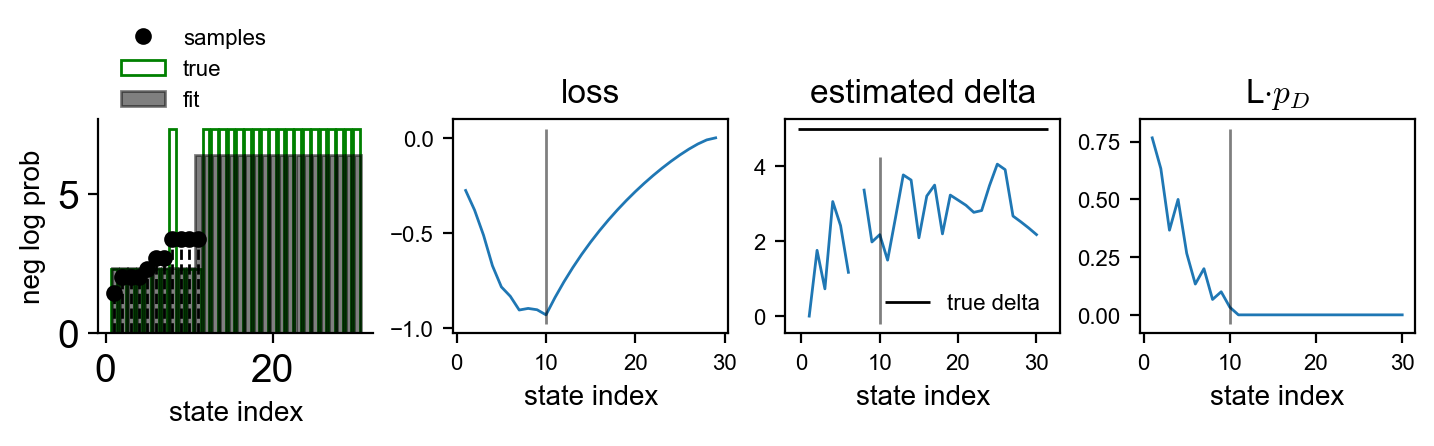

PyObject <matplotlib.legend.Legend object at 0x337bb29f0>

In [13]:
fig, ax = subplots( 1,4, figsize=set_size_for_paper(2, 0.3), dpi=200, constrained_layout=true )

function plot_ptrue_and_fit_1(true_probs, pfit, freqs, most_to_least_idx, ax)
    m_to_l=most_to_least_idx
    N_states = length( true_probs )
    ax.bar(collect(1:N_states), -log.(true_probs[m_to_l]), label="true", color="none", ec="green",  );
    # bar(collect(1:N_states).+0.01, freqs, alpha=0.5, color="yellow", label="sample" );
    ax.bar(collect(1:N_states).+0.125 , -log.(pfit[m_to_l]), alpha=0.5, color="black", label="fit", ec="black");
    # plot(collect(1:N_states),1.1maximum(pfit)*(.! Bool.(L̂i)), ".")
    ax.plot(collect(1:N_states),-log.(freqs[m_to_l]), linewidth=0, marker="o", 
        color="black", markeredgecolor="k", label="samples")
    for (x, f) in zip(collect(1:N_states), -log.(freqs[m_to_l]))
        ax.vlines(x, 0, f, linestyle="--", color="k")
    end
    # ax.set_xticks(collect(1:10))
    ax.spines["right"].set_visible(false)
    ax.spines["top"].set_visible(false)
    ax.legend( frameon=false, loc=(0.05,1.))
    ax.set_xlabel("state index")# fontsize=14)
    ax.set_ylabel("neg log prob")# fontsize=14)
    ax.tick_params(axis="both", which="major", labelsize=14)
end

plot_ptrue_and_fit_1(true_probs, pfit, freqs, m_to_l, ax[1])

ax[2].plot( collect(1:N_states), minl_m_to_l )
ax[3].plot( collect(1:N_states), Δs[m_to_l] )
ax[4].plot( collect(1:N_states), Lp[m_to_l] )
ax[2].set_title("loss")
ax[3].set_title("estimated delta")
ax[4].set_title("L"*L"\cdot p_{D}")
for a in ax
    a.tick_params(axis="both", which="major")
    a.set_xlabel("state index")
end
for i in 2:4
    ax[i].vlines( findmin(minl_m_to_l)[2], ax[i].get_ylim()..., color="k", alpha=0.5)
end
# ax[4].plot(collect(1:N_states), (N_states.-collect(1:N_states))./N_states )
ax[3].hlines(Δtrue, ax[4].get_xlim()..., color="k", label="true delta")
ax[3].legend(frameon=false, loc="lower right")

# nearest neighbor ising model

In [29]:
include(srcdir("nearest_neighbor_ising.jl"))

drawsamples_exact (generic function with 1 method)

### generate training data

In [30]:
nn_dims = (4,4) # 4 by 4 nearest neighbor ising model
θ, Jij=init_2dNN(4,4);  # for ground truth model

Jstart = init_Jfit(size(Jij)[1]);
ml_exact_buffer = ml_exact_buffer=ExactMLBuffer(Jij);

In [31]:
temp = 3.33
nsampless = 800
zz=drawsamples_exact( ml_exact_buffer, Jij, temp, nsampless)

16×800 Matrix{Float64}:
  1.0   1.0   1.0  -1.0   1.0  -1.0  …   1.0  -1.0   1.0  -1.0  -1.0  -1.0
  1.0  -1.0  -1.0  -1.0   1.0   1.0      1.0  -1.0   1.0  -1.0   1.0  -1.0
  1.0   1.0  -1.0   1.0   1.0  -1.0      1.0  -1.0  -1.0  -1.0   1.0  -1.0
  1.0   1.0   1.0   1.0   1.0  -1.0      1.0  -1.0   1.0  -1.0   1.0   1.0
 -1.0   1.0   1.0   1.0   1.0  -1.0      1.0  -1.0   1.0  -1.0  -1.0  -1.0
 -1.0  -1.0  -1.0   1.0   1.0  -1.0  …   1.0  -1.0  -1.0  -1.0  -1.0  -1.0
  1.0   1.0  -1.0   1.0   1.0  -1.0      1.0  -1.0  -1.0  -1.0   1.0  -1.0
  1.0   1.0   1.0   1.0   1.0  -1.0      1.0  -1.0   1.0  -1.0   1.0  -1.0
  1.0   1.0  -1.0   1.0  -1.0  -1.0      1.0  -1.0  -1.0  -1.0   1.0  -1.0
  1.0   1.0  -1.0   1.0   1.0  -1.0      1.0  -1.0   1.0  -1.0   1.0  -1.0
  1.0   1.0  -1.0   1.0   1.0  -1.0  …   1.0  -1.0   1.0  -1.0   1.0  -1.0
  1.0   1.0  -1.0   1.0   1.0   1.0      1.0  -1.0   1.0  -1.0   1.0  -1.0
  1.0   1.0  -1.0  -1.0   1.0  -1.0      1.0  -1.0  -1.0  -1.0   1.0  -1.0
 

### fit model

In [34]:
fit_opts= FitOptions2spinExact(Jstart;learning_rate=0.01, 
    relTol=1e-5, max_iter=10000, showevery=500)

FitOptions2spinExact{Float64}
  learning_rate: Float64 0.01
  relTol: Float64 1.0e-5
  max_iter: Int64 10000
  showevery: Int64 500


In [36]:
Jfit, negloglikes=ml_fit_Jij(Jstart, zz, fit_opts, ml_exact_buffer;
                                             silent=false);

iter = 0, -likelihood = 32.010139482791445
   logZ=[29.02940748809798]
   mean energy of train data = [2.980731994693461]
iter = 500, -likelihood = 9.121690540017402
   logZ=[14.007136211335663]
   mean energy of train data = [-4.88544567131826]
iter = 1000, -likelihood = 8.575454255477053
   logZ=[13.129742495926875]
   mean energy of train data = [-4.5542882404498215]
iter = 1322, -likelihood = 8.520391163401461
relTol of 1.0e-5 reached




### plot results

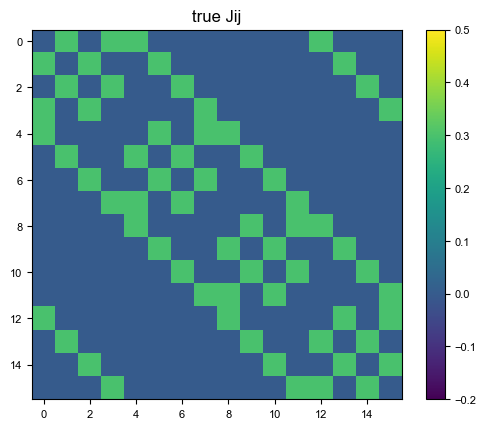

PyObject Text(0.5, 1.0, 'true Jij')

In [39]:
imshow(Jij/temp , clim=(-.2,.5))
colorbar()
title("true Jij")

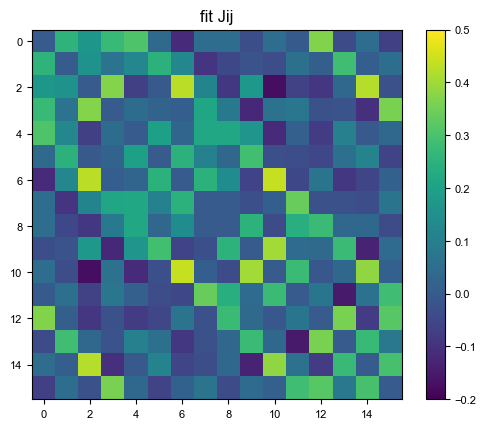

PyObject Text(0.5, 1.0, 'fit Jij')

In [40]:
imshow(Jfit, clim=(-.2,.5))
colorbar()
title("fit Jij")